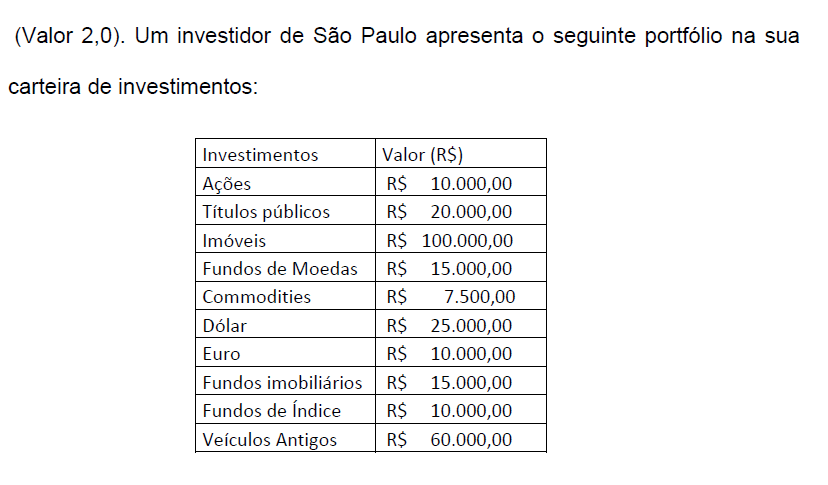

In [12]:
# Dados / informações
investimentos <- c("Ações", "Títulos Públicos", "Imóveis", "Fundos de Moedas", "Commodities","Dólar", "Euros", "FIIs", "Fundos de Índice", "Veículos Antigos")
valor <- c(10,20,100,15,7.5,25,10,15,10,60)

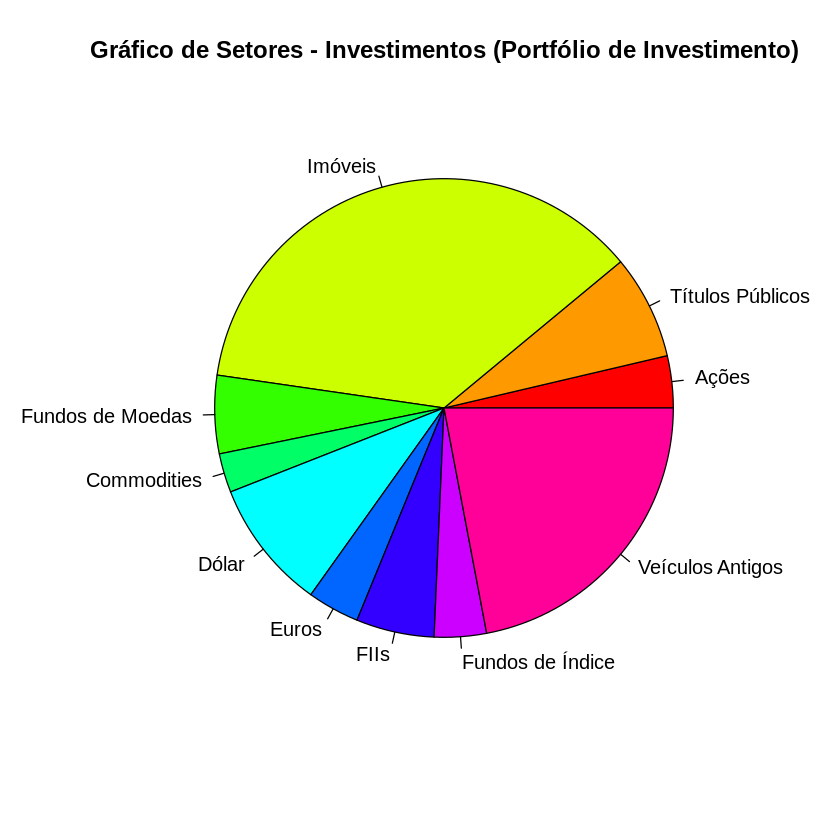

In [13]:
# Gráfico de setores
pie(valor,
    labels = investimentos,
    main = "Gráfico de Setores - Investimentos (Portfólio de Investimento)",
    col = rainbow(length(valor)))


In [20]:
# Usando as porcentagens
porcentagens <- round(valor / sum(valor) * 100, 2)
porcentagens

[1]  3.67  7.34 36.70  5.50  2.75  9.17  3.67  5.50  3.67 22.02

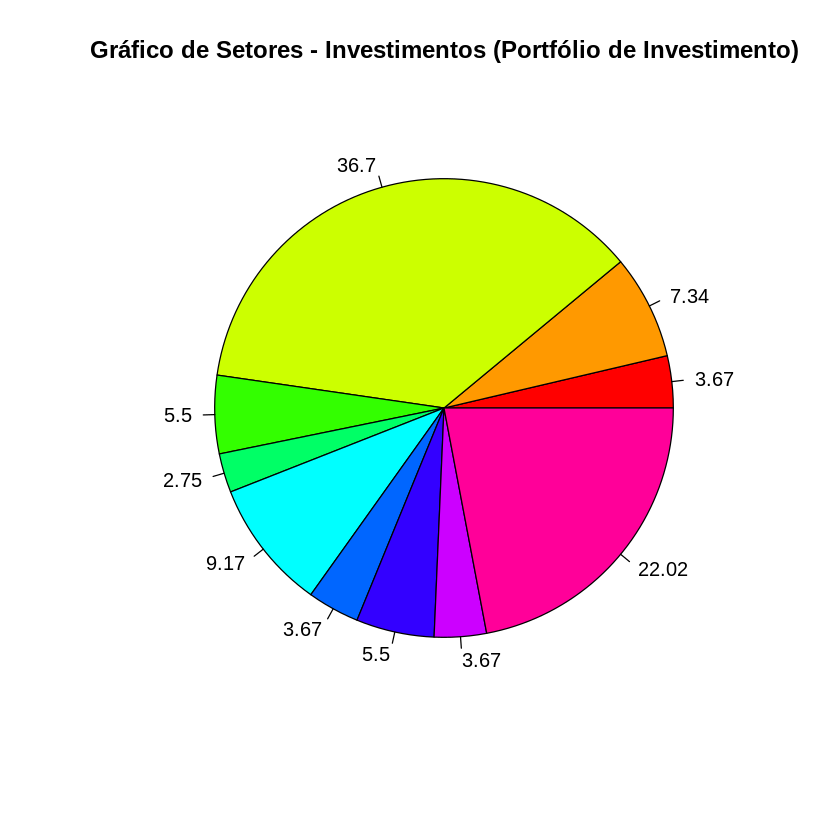

In [21]:
# Gráfico de setores
pie(valor,
    labels = porcentagens,
    main = "Gráfico de Setores - Investimentos (Portfólio de Investimento)",
    col = rainbow(length(valor)))

In [28]:
# Criação dos rótulos: Valor  - investimento%
rotulos <- paste0(investimentos, " (R$ ", valor, ") - ", porcentagens, "%")
rotulos

[1] "Ações (R$ 10) - 3.67%"             "Títulos Públicos (R$ 20) - 7.34%" 
 [3] "Imóveis (R$ 100) - 36.7%"          "Fundos de Moedas (R$ 15) - 5.5%"  
 [5] "Commodities (R$ 7.5) - 2.75%"      "Dólar (R$ 25) - 9.17%"            
 [7] "Euros (R$ 10) - 3.67%"             "FIIs (R$ 15) - 5.5%"              
 [9] "Fundos de Índice (R$ 10) - 3.67%"  "Veículos Antigos (R$ 60) - 22.02%"

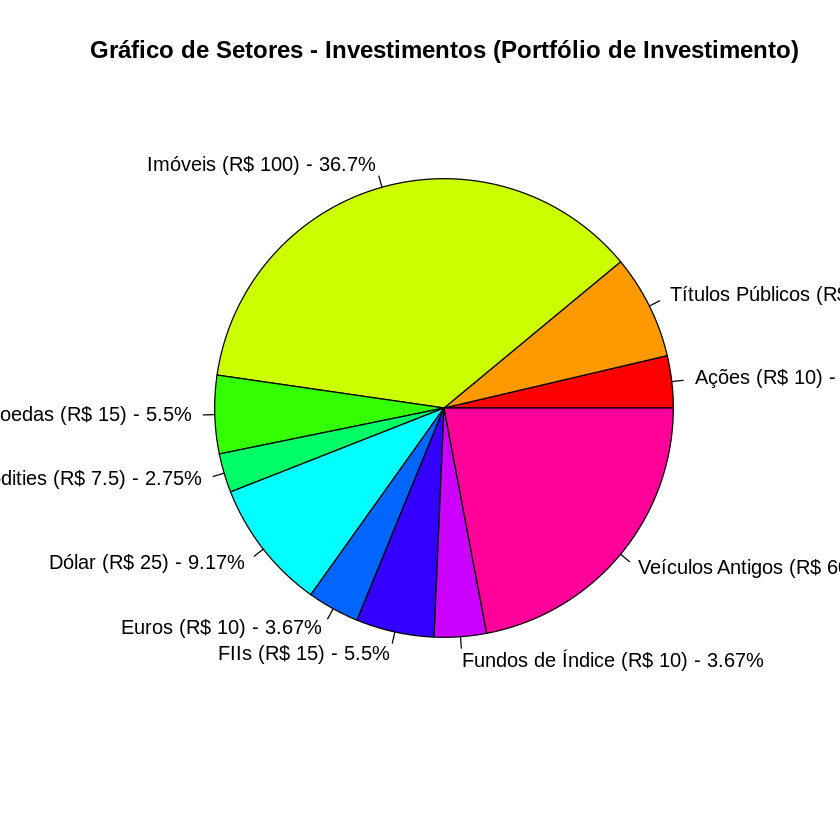

In [40]:
# Gráfico de setores
pie(valor,
    labels = rotulos,
    main = "Gráfico de Setores - Investimentos (Portfólio de Investimento)",
    col = rainbow(length(valor)))

In [41]:
# Índices do maior e menor valor encontrados no portfólio
idx_maior <- which.max(valor)
idx_menor <- which.min(valor)

In [42]:
# Vetor de explosão: 0 para não destacar, valor > 0 para destacar
explodir <- rep(0, length(valor))
explodir[idx_maior] <- 0.2
explodir[idx_menor] <- 0.2

In [64]:
library(ggplot2)
options(repr.plot.width = 14, repr.plot.height = 10)

In [60]:
#install.packages("plotrix")
install.packages("IRdisplay")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



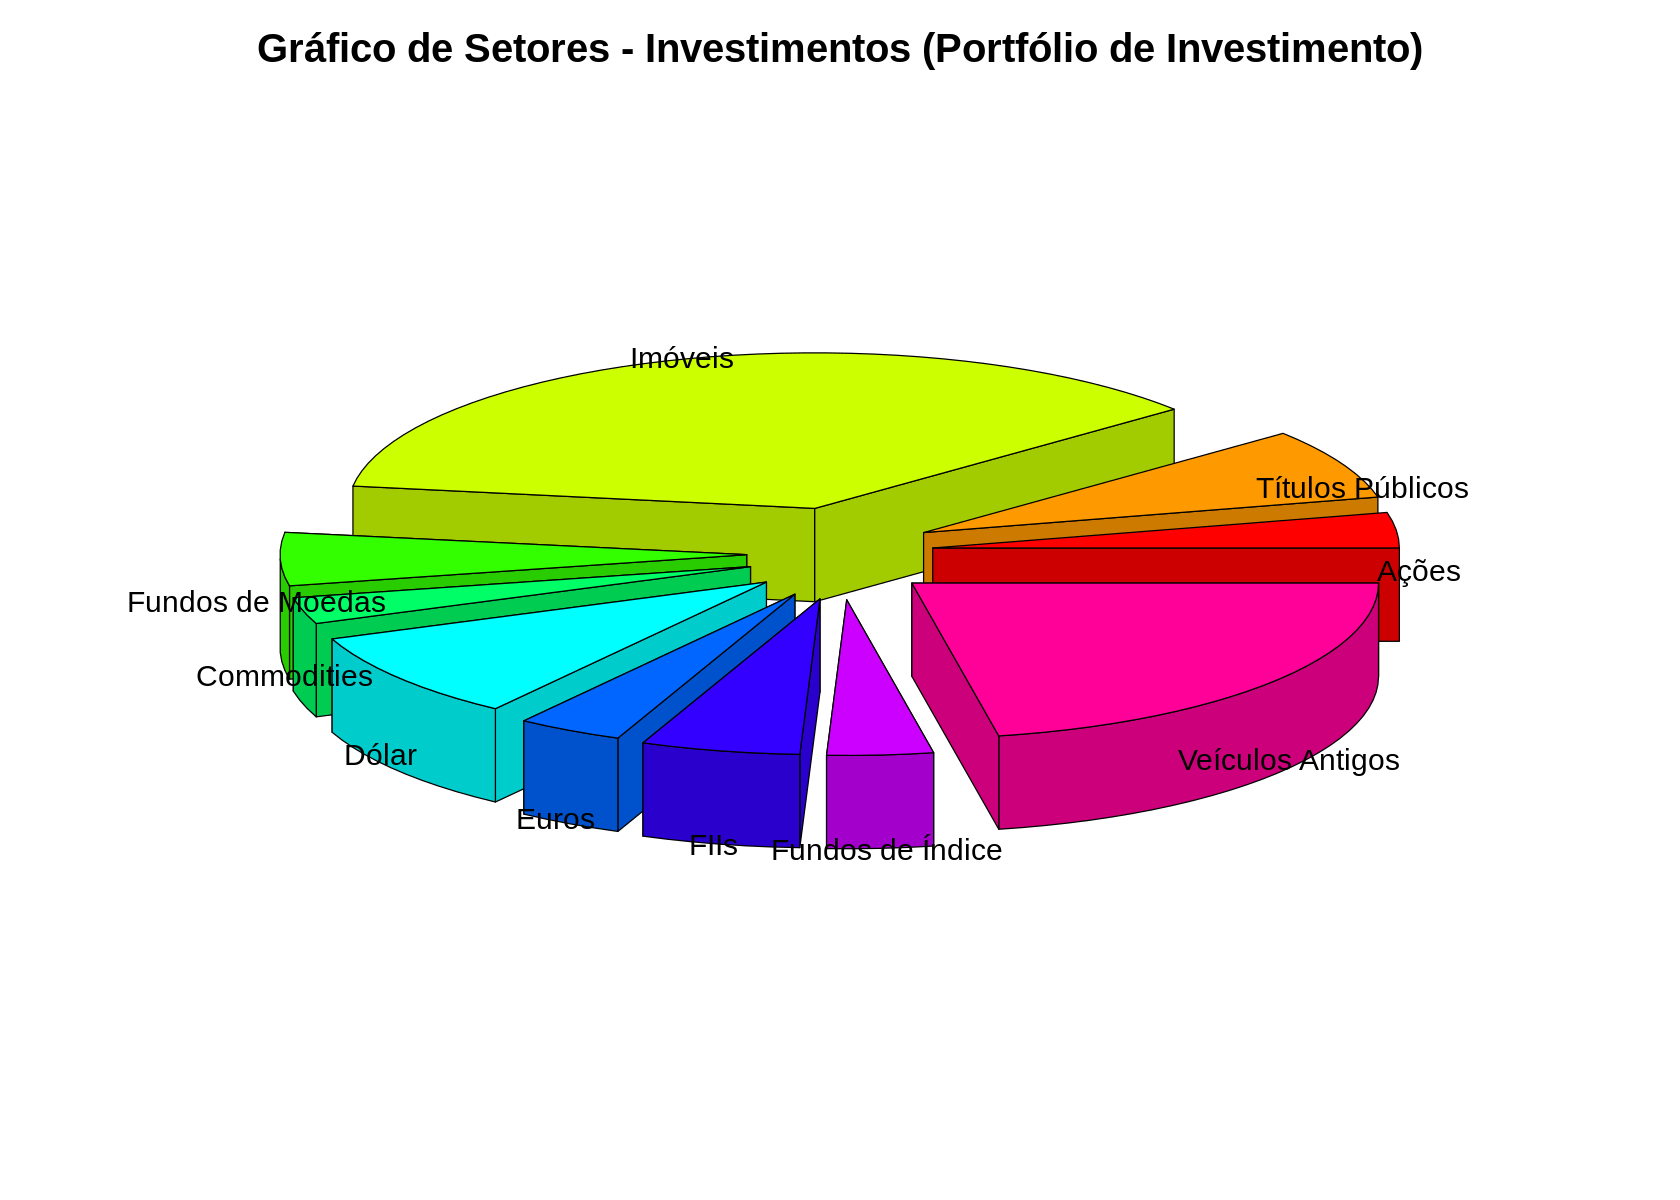

In [84]:
library(plotrix)
library(IRdisplay)
pie3D(valor,
      labels = investimentos,
      explode = 0.2,
      main = "Gráfico de Setores - Investimentos (Portfólio de Investimento)",
      cex.main = 2,
      col = rainbow(length(valor)),
      labelcex = 1.5,
      labelcol = "black",
    #  labelpos = 2,
      )


In [86]:
portfolio <- data.frame(
  categoria = investimentos,
  valor = valor
)

In [87]:
portfolio

categoria,valor
<chr>,<dbl>
Ações,10.0
Títulos Públicos,20.0
Imóveis,100.0
Fundos de Moedas,15.0
Commodities,7.5
Dólar,25.0
Euros,10.0
FIIs,15.0
Fundos de Índice,10.0


In [89]:
# Calcular a porcentagem de cada valor
portfolio <- portfolio %>%
  mutate(porcentagem = round(valor / sum(valor) * 100, 1))
portfolio

categoria,valor,porcentagem
<chr>,<dbl>,<dbl>
Ações,10.0,3.7
Títulos Públicos,20.0,7.3
Imóveis,100.0,36.7
Fundos de Moedas,15.0,5.5
Commodities,7.5,2.8
Dólar,25.0,9.2
Euros,10.0,3.7
FIIs,15.0,5.5
Fundos de Índice,10.0,3.7


In [92]:
# Identificar o maior e o menor valor
portfolio <- portfolio %>%
  mutate(destaque = case_when(
    valor == max(valor) ~ "Maior",  # Maior valor
    valor == min(valor) ~ "Menor",  # Menor valor
    TRUE ~ "--"  # Outros valores
  ))

portfolio

categoria,valor,porcentagem,destaque
<chr>,<dbl>,<dbl>,<chr>
Ações,10.0,3.7,--
Títulos Públicos,20.0,7.3,--
Imóveis,100.0,36.7,Maior
Fundos de Moedas,15.0,5.5,--
Commodities,7.5,2.8,Menor
Dólar,25.0,9.2,--
Euros,10.0,3.7,--
FIIs,15.0,5.5,--
Fundos de Índice,10.0,3.7,--


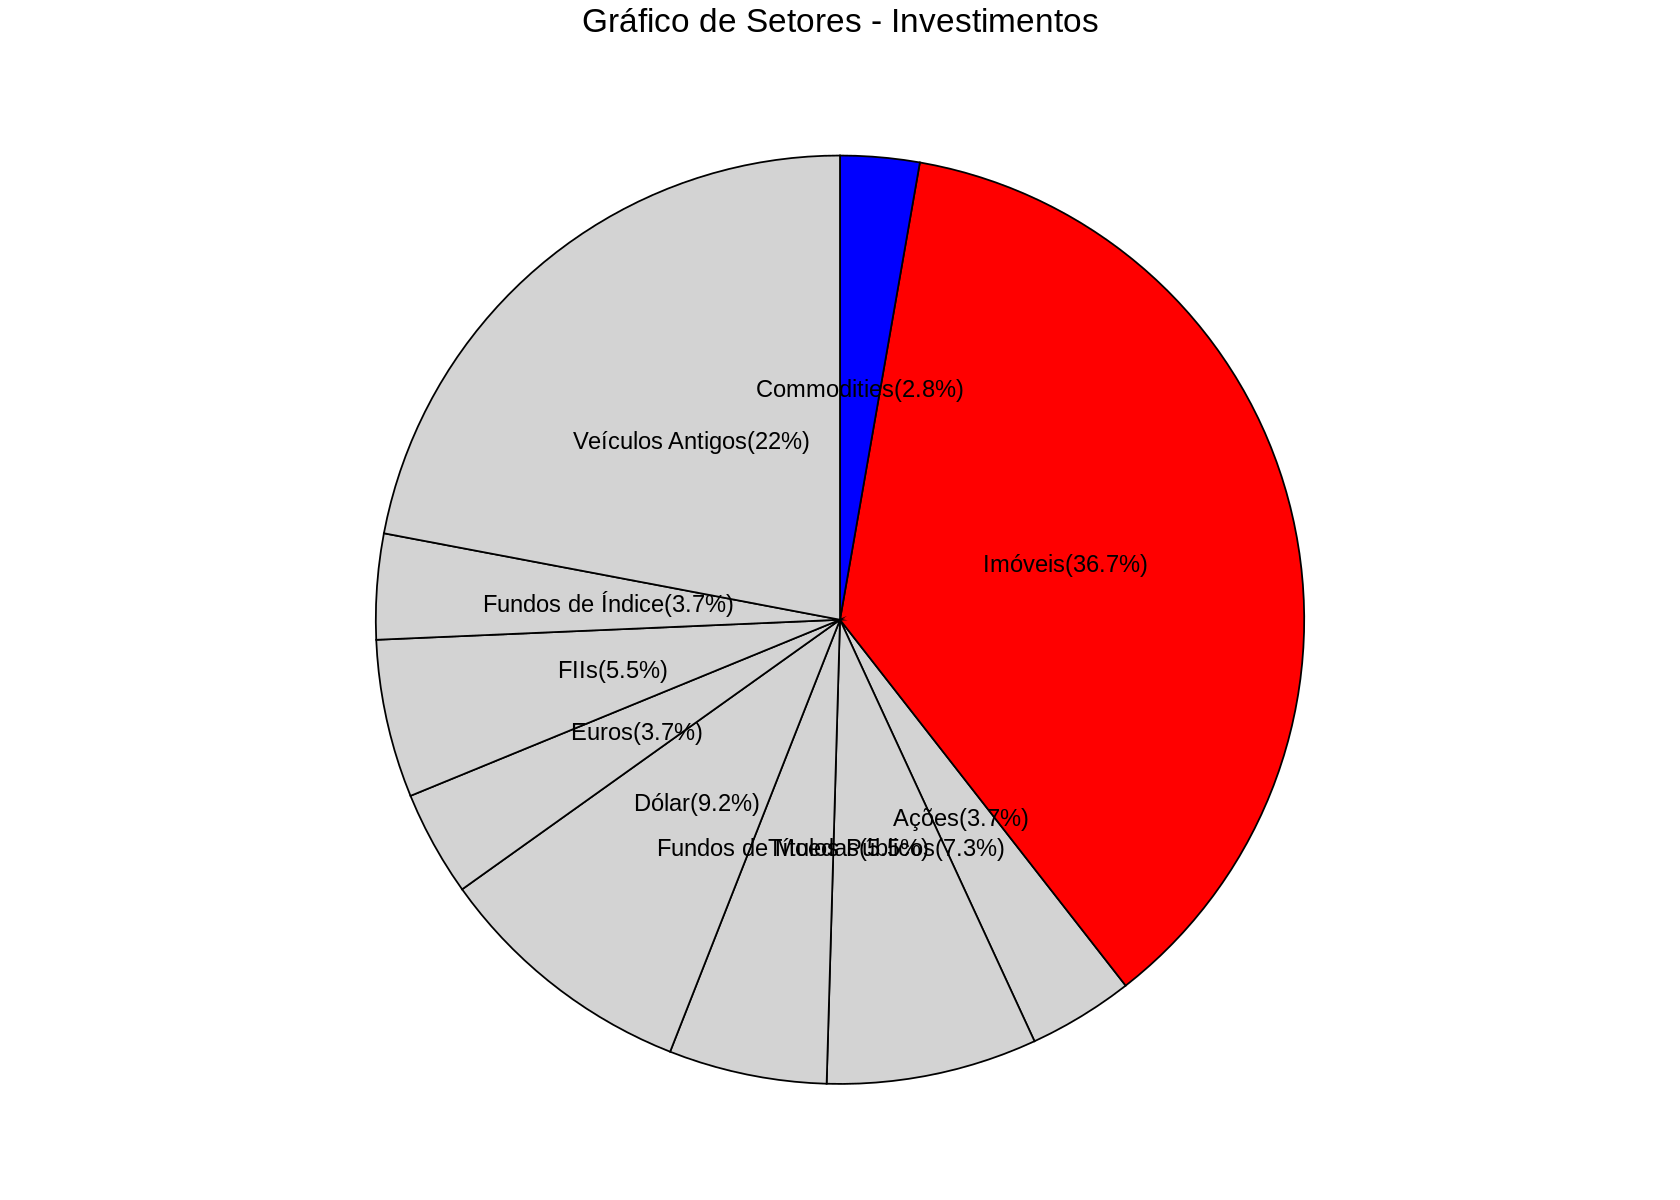

In [110]:
# Plotar o gráfico de setores com destaque
ggplot(portfolio, aes(x = "", y = valor, fill = destaque)) +
  geom_bar(stat = "identity", width = 1, color = "black") +  # Gráfico de setores
  coord_polar(theta = "y") +  # Transformar em gráfico de setores (pizza)
  geom_text(aes(label = paste(categoria, "(", porcentagem, "%)", sep = "")),
            position = position_stack(vjust = 0.5), color = "black", size = 5, ) +  # Rótulos
  scale_fill_manual(values = c("Maior" = "red", "Menor" = "blue", "--" = "lightgray")) +  # Cores para destaque
  theme_void() +  # Remover o fundo
  theme(legend.position = "center") +  # Remover a legenda
  labs(title = "Gráfico de Setores - Investimentos")+
  theme(legend.position = "none",   # Remover a legenda
        plot.title = element_text(size = 20, hjust=0.5))   # Ajustar o tamanho do título